In [128]:
import kagglehub
import pandas as pd
import os
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import KFold, train_test_split, GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, ConfusionMatrixDisplay

In [129]:
path = kagglehub.dataset_download(
    'gyanashish/healthcare-diabetes'
)

In [130]:
filename = os.listdir(path)[0]
ds = pd.read_csv(os.path.join(path, filename))

## Задание 1

In [131]:
print(int(ds['Outcome'].mean() * 100), '%')

34 %


## Задание 2

In [132]:
print(ds.groupby('Outcome')['BloodPressure'].mean())
ds0 = ds[ds['Outcome'] == 0] # Здоровые
ds1 = ds[ds['Outcome'] == 1] # Больные
print(ds0['BloodPressure'].mean())
print(ds1['BloodPressure'].mean())

Outcome
0    68.184000
1    70.824627
Name: BloodPressure, dtype: float64
68.184
70.82462686567165


## Задание 3

                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.129459       0.141282      -0.081672   
Glucose                      0.129459  1.000000       0.152590       0.057328   
BloodPressure                0.141282  0.152590       1.000000       0.207371   
SkinThickness               -0.081672  0.057328       0.207371       1.000000   
Insulin                     -0.073535  0.331357       0.088933       0.436783   
BMI                          0.017683  0.221071       0.281805       0.392573   
DiabetesPedigreeFunction    -0.033523  0.137337       0.041265       0.183928   
Age                          0.544341  0.263514       0.239528      -0.113970   
Outcome                      0.221898  0.466581       0.065068       0.074752   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies              -0.073535  0.017683                 -0.033523   
Glucose                   0.331357  0.221

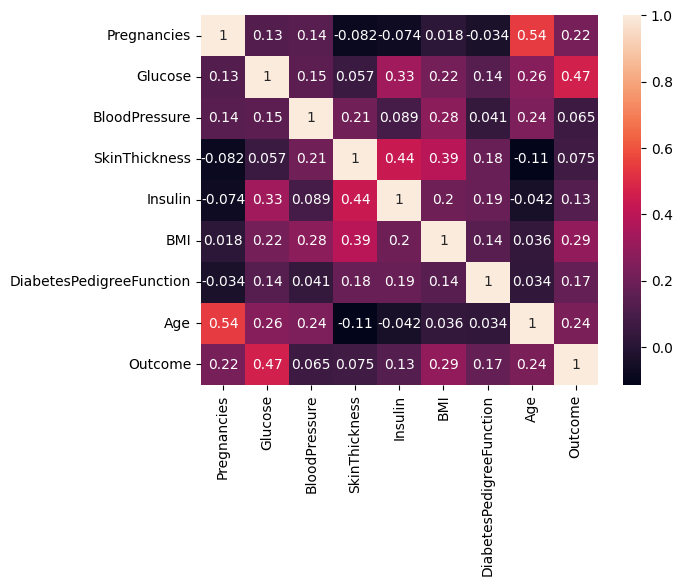

In [133]:
print(ds.corr(numeric_only=True))

sns.heatmap(ds.corr(numeric_only=True), annot=True)
plt.show()

## Задание 4

In [134]:
X = ds.drop('Outcome', axis=1)
y = ds['Outcome']
mic = mutual_info_classif(X, y, random_state = 54)
print(mic)
feature = pd.Series(mic, index=X.columns)
feature = feature.sort_values(ascending=False)
print(feature)

[0.05628168 0.11923576 0.0101025  0.03705369 0.03025116 0.08688107
 0.01909568 0.0639107 ]
Glucose                     0.119236
BMI                         0.086881
Age                         0.063911
Pregnancies                 0.056282
SkinThickness               0.037054
Insulin                     0.030251
DiabetesPedigreeFunction    0.019096
BloodPressure               0.010103
dtype: float64


## Задание 5

In [135]:
kf = KFold(n_splits=5, shuffle=True, random_state = 54)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=54)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19],
    'weights': ['uniform', 'distance'],
    'metric': ['minkowski', 'euclidean', 'cosine']
}
knn = KNeighborsClassifier()
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=kf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)
print(grid_search.best_params_)
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test_scaled)
print(f"Accuracy на тесте: {accuracy_score(y_test, y_pred):.4f}")


Fitting 5 folds for each of 54 candidates, totalling 270 fits
{'metric': 'cosine', 'n_neighbors': 17, 'weights': 'distance'}
Accuracy на тесте: 0.7597


## Задание 6

In [142]:
kf = KFold(n_splits=5, shuffle=True, random_state = 54)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=54)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
param_grid = {
    'n_neighbors': range(3, 21) ,
    'weights': ['uniform', 'distance'],
    'metric': ['minkowski', 'euclidean', 'cosine']
}
knn = KNeighborsClassifier()
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=kf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)
print(grid_search.best_params_)
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test_scaled)
print(f"Accuracy на тесте: {accuracy_score(y_test, y_pred):.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
{'metric': 'cosine', 'n_neighbors': 12, 'weights': 'distance'}
Accuracy на тесте: 0.7559


## Задание 7

Точность: 0.7403, Соседи: 2
Точность: 0.7273, Соседи: 3
Точность: 0.7662, Соседи: 4
Точность: 0.7662, Соседи: 5
Точность: 0.7532, Соседи: 6
Точность: 0.7532, Соседи: 7
Точность: 0.7403, Соседи: 8
Точность: 0.7338, Соседи: 9
Точность: 0.7532, Соседи: 10
Точность: 0.7273, Соседи: 11
Точность: 0.7597, Соседи: 12
Точность: 0.7338, Соседи: 13
Точность: 0.7403, Соседи: 14
Точность: 0.7338, Соседи: 15


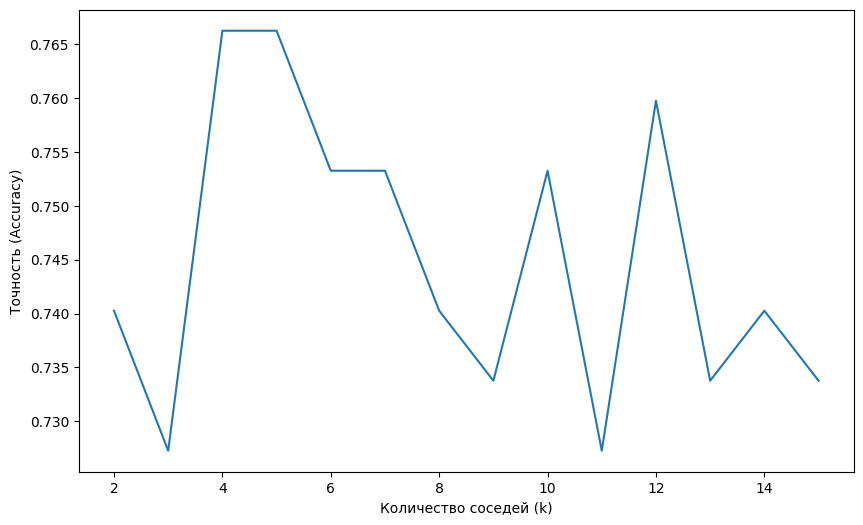

In [152]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=54)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
kf = KFold(n_splits=5, shuffle=True, random_state=54)
scores = []
neighbors = range(2, 16) 
for i in neighbors:
    knn = KNeighborsClassifier(n_neighbors=i, metric='cosine')
    knn.fit(X_train_scaled, y_train) 
    score = knn.score(X_test_scaled, y_test)
    print(f'Точность: {score:.4f}, Соседи: {i}')
    scores.append(score)
plt.figure(figsize=(10, 6))
plt.plot(neighbors, scores)
plt.xlabel('Количество соседей (k)')
plt.ylabel('Точность (Accuracy)')
plt.show()

## Задание 8